In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn import metrics

from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    recall_score,
    precision_score,
    average_precision_score,
    f1_score,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [2]:
# Đọc dữ liệu
salary_data = pd.read_csv("salary_synthetic.csv")

salary_data.shape

(2000, 15)

In [3]:
salary_data.head()

,age,gender,education,experience_years,role_seniority,company_size,location_tier,skills_count,certifications,worked_remote,last_promotion_years_ago,salary_bdt,recent_project_description_length,survey_date,recent_note
0,33,Male,M.Sc,6.0,Senior,Enterprise,Tier-2,1.0,2.0,1,0.0,145185,57.0,2024-11-15,Worked on microservices deployment
1,29,Male,M.Sc,9.0,Junior,Enterprise,Remote,5.0,0.0,1,0.0,121262,50.0,2024-03-08,Built ML pipeline for preprocessing
2,34,Male,B.Sc+Cert,NaN,Lead,Enterprise,Remote,5.0,1.0,1,5.0,184875,50.0,2024-09-01,Experience in data cleaning and ETL
3,39,Male,B.Sc,16.0,Mid,Enterprise,Tier-1,5.0,0.0,1,3.0,180105,59.0,2024-01-26,Contributed to open-source NLP repo
4,29,Female,B.Sc,8.0,Junior,SME,Tier-1,5.0,2.0,0,7.0,114750,NaN,2023-12-08,Built ML pipeline for preprocessing


### Khám phá dữ liệu

Tập dữ liệu chứa thông tin về nhân viên như tuổi, giới tính, trình độ học vấn,
kinh nghiệm làm việc, kỹ năng, chứng chỉ, điều kiện làm việc, lịch sử thăng chức
và mức lương.

Biến mục tiêu trong các bài toán hồi quy là `salary_bdt`.

In [4]:
salary_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                2000 non-null   int64  
 1   gender                             2000 non-null   object 
 2   education                          1900 non-null   object 
 3   experience_years                   1840 non-null   float64
 4   role_seniority                     2000 non-null   object 
 5   company_size                       2000 non-null   object 
 6   location_tier                      2000 non-null   object 
 7   skills_count                       1800 non-null   float64
 8   certifications                     1920 non-null   float64
 9   worked_remote                      2000 non-null   int64  
 10  last_promotion_years_ago           1880 non-null   float64
 11  salary_bdt                         2000 non-null   int64

In [5]:
salary_data.isnull().sum()

age                                    0
gender                                 0
education                            100
experience_years                     160
role_seniority                         0
company_size                           0
location_tier                          0
skills_count                         200
certifications                        80
worked_remote                          0
last_promotion_years_ago             120
salary_bdt                             0
recent_project_description_length    240
survey_date                            0
recent_note                          300
dtype: int64

# 1. Simple Linear Regression

Simple Linear Regression sử dụng **một biến độc lập** để dự đoán **một biến phụ thuộc liên tục**.
Trong bài này, `salary_bdt` là biến phụ thuộc và `experience_years` được chọn làm biến độc lập.

### Kiểm tra tương quan

Trước khi xây dựng mô hình, ta kiểm tra tương quan giữa các biến số và `salary_bdt`
để tìm biến có mối quan hệ tuyến tính đáng chú ý với mức lương.

Hệ số tương quan Pearson nằm trong khoảng từ -1 đến 1:

- Gần 1: tương quan tuyến tính thuận mạnh.
- Gần -1: tương quan tuyến tính nghịch mạnh.
- Gần 0: tương quan tuyến tính yếu.

Tương quan chỉ phản ánh mối quan hệ tuyến tính, không chứng minh quan hệ nhân quả.

In [6]:
# Chọn các biến có kiểu dữ liệu số
numeric_data = salary_data.select_dtypes(include=np.number)

numeric_data.columns

Index(['age', 'experience_years', 'skills_count', 'certifications',
       'worked_remote', 'last_promotion_years_ago', 'salary_bdt',
       'recent_project_description_length'],
      dtype='object')

In [7]:
corr = numeric_data.corr()
corr

,age,experience_years,skills_count,certifications,worked_remote,last_promotion_years_ago,salary_bdt,recent_project_description_length
age,1.000000,0.930218,-0.015152,-0.030424,-0.031376,-0.016256,0.765101,-0.001742
experience_years,0.930218,1.000000,-0.032282,-0.035930,-0.036534,-0.021014,0.826231,-0.005472
skills_count,-0.015152,-0.032282,1.000000,-0.015025,-0.011781,-0.003384,0.037809,-0.003638
certifications,-0.030424,-0.035930,-0.015025,1.000000,0.044998,0.003233,0.015044,0.026025
worked_remote,-0.031376,-0.036534,-0.011781,0.044998,1.000000,-0.024372,0.011874,0.008350
last_promotion_years_ago,-0.016256,-0.021014,-0.003384,0.003233,-0.024372,1.000000,-0.015071,-0.031173
salary_bdt,0.765101,0.826231,0.037809,0.015044,0.011874,-0.015071,1.000000,-0.015976
recent_project_description_length,-0.001742,-0.005472,-0.003638,0.026025,0.008350,-0.031173,-0.015976,1.000000


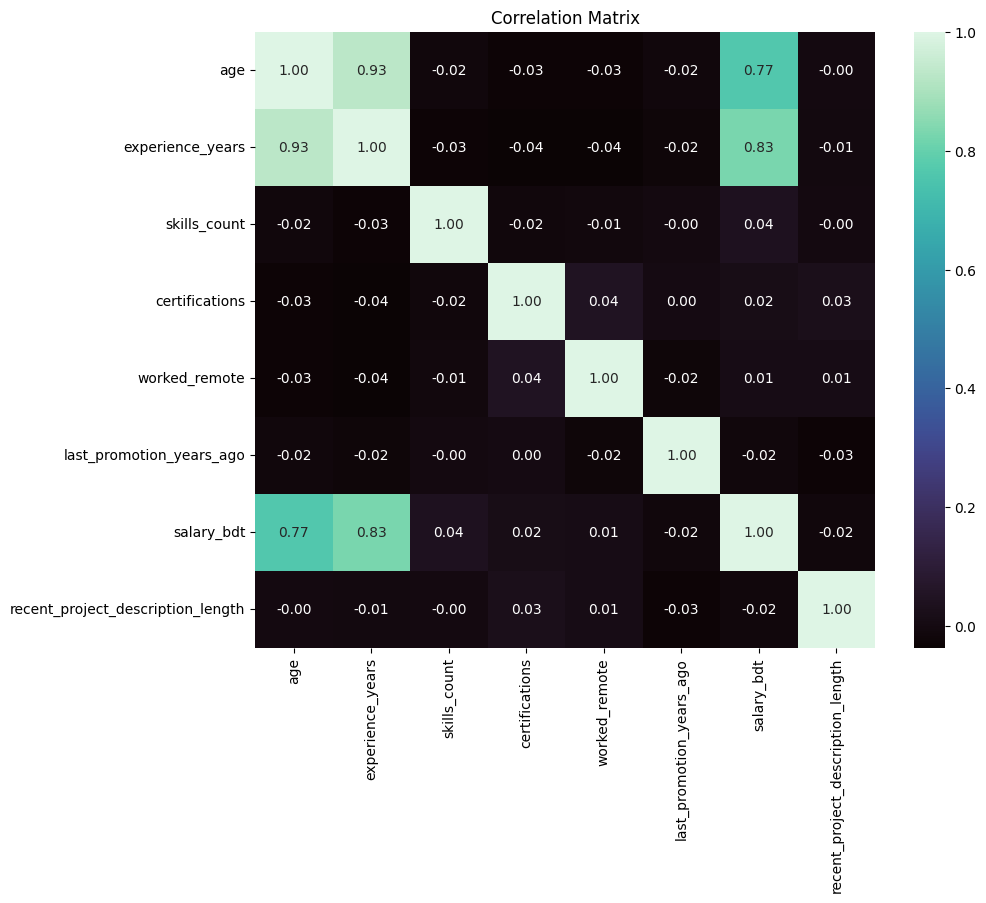

In [8]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='mako'
)

plt.title('Correlation Matrix')
plt.show()

`experience_years` có tương quan thuận mạnh nhất với `salary_bdt` trong các biến số,
vì vậy biến này được chọn cho Simple Linear Regression.

`experience_years` có 160 giá trị thiếu nên các dòng thiếu giá trị này sẽ được loại bỏ
trước khi huấn luyện mô hình.

In [9]:
# Chọn một biến độc lập để dự đoán biến phụ thuộc
selected_feature = 'experience_years'

X = salary_data[[selected_feature]]
y = salary_data['salary_bdt']

In [10]:
# Loại các dòng có giá trị thiếu
model_data = salary_data[
    [selected_feature, 'salary_bdt']
].dropna()

model_data.shape

(1840, 2)

In [11]:
X = model_data[[selected_feature]]
y = model_data['salary_bdt']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1840, 1)
y shape: (1840,)


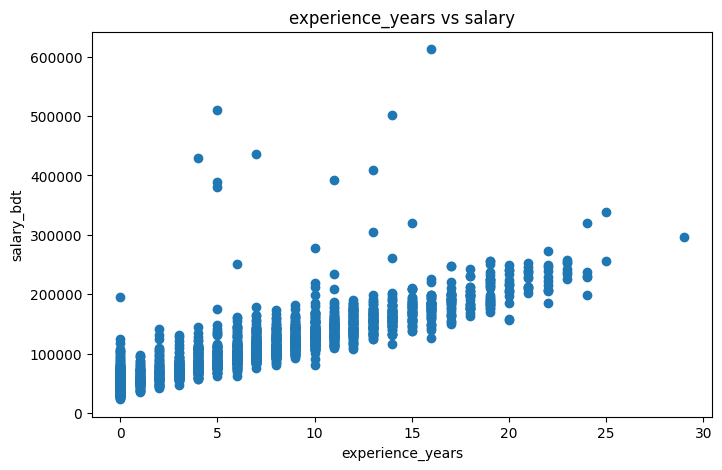

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[selected_feature],
    y
)

plt.xlabel(selected_feature)
plt.ylabel('salary_bdt')
plt.title(f'{selected_feature} vs salary')

plt.show()

In [13]:
# Chia dữ liệu thành tập Train và Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=4
)

In [14]:
slr = LinearRegression()
slr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Hệ số của mô hình

Phương trình Simple Linear Regression có dạng:

`y = β₀ + β₁x`

Trong đó:

- `β₀` là hệ số chặn (intercept), tức mức lương dự đoán khi `x = 0`.
- `β₁` là hệ số của biến độc lập, cho biết mức thay đổi dự đoán của `salary_bdt`
  khi `x` tăng 1 đơn vị.

In [15]:
slr.intercept_

np.float64(55467.0944840571)

In [16]:
slr.coef_

array([7916.17122136])

In [17]:
print("Intercept (β0):", slr.intercept_)
print("Coefficient (β1):", slr.coef_[0])

print(
    f"Regression equation: "
    f"salary_bdt = {slr.intercept_:.2f} + "
    f"{slr.coef_[0]:.2f} × {selected_feature}"
)

Intercept (β0): 55467.0944840571
Coefficient (β1): 7916.17122136164
Regression equation: salary_bdt = 55467.09 + 7916.17 × experience_years


In [18]:
# Dự đoán trên tập Train và Test
y_pred_train = slr.predict(X_train)
y_pred_test = slr.predict(X_test)

In [19]:
prediction_result = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred_test
})

prediction_result.head(10)

,Actual Salary,Predicted Salary
0,211922,197958.176469
1,126360,118796.464255
2,62122,55467.094484
3,87071,63383.265705
4,149851,142544.977919
5,150363,150461.149140
6,91963,110880.293034
7,156630,174209.662804
8,169169,150461.149140
9,168780,158377.320362


### Đánh giá mô hình

Mô hình được đánh giá bằng:

- **R² (Coefficient of Determination):** mức độ biến thiên của biến mục tiêu được mô hình giải thích.
- **MAE (Mean Absolute Error):** sai số tuyệt đối trung bình.
- **MSE (Mean Squared Error):** trung bình bình phương sai số.

Các chỉ số được tính riêng trên tập Train và Test để đánh giá khả năng học và khả năng tổng quát hóa.

In [20]:
print("Training Evaluation")
print("-------------------")

print("R²:", metrics.r2_score(y_train, y_pred_train))
print("MAE:", metrics.mean_absolute_error(y_train, y_pred_train))
print("MSE:", metrics.mean_squared_error(y_train, y_pred_train))

Training Evaluation
-------------------
R²: 0.7177649073535215
MAE: 16321.808906796909
MSE: 761111349.8116037


In [21]:
print("Testing Evaluation")
print("------------------")

print("R²:", metrics.r2_score(y_test, y_pred_test))
print("MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_test))

Testing Evaluation
------------------
R²: 0.6228721756582922
MAE: 18626.03542525135
MSE: 1443178137.112926


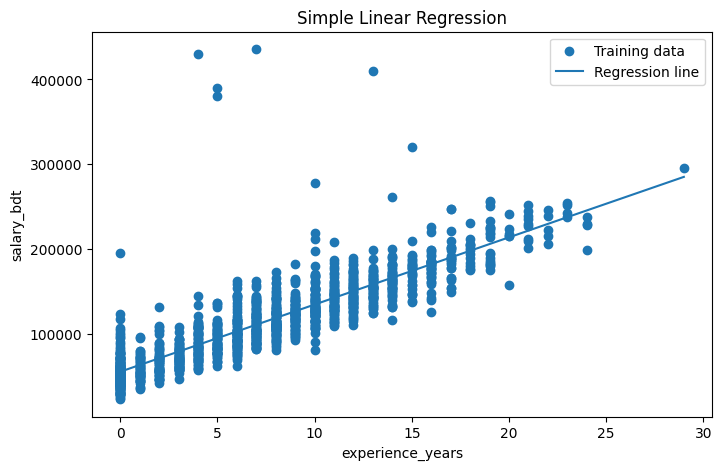

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train[selected_feature],
    y_train,
    label='Training data'
)

# Sắp xếp X để đường hồi quy hiển thị đúng
sort_idx = np.argsort(X_train[selected_feature].values)

plt.plot(
    X_train[selected_feature].values[sort_idx],
    y_pred_train[sort_idx],
    label='Regression line'
)

plt.xlabel(selected_feature)
plt.ylabel('salary_bdt')
plt.title('Simple Linear Regression')
plt.legend()

plt.show()

# 2. Multiple Linear Regression

Multiple Linear Regression sử dụng **nhiều biến độc lập** để dự đoán một biến phụ thuộc liên tục.

Dựa trên ma trận tương quan, ta chọn ba biến có tương quan đáng chú ý với `salary_bdt`:

- `experience_years`
- `age`
- `skills_count`

Biến mục tiêu là `salary_bdt`.

In [23]:
X_multi = salary_data[
    ['experience_years', 'age', 'skills_count']
]

y_multi = salary_data['salary_bdt']

print("Independent variables:")
print(X_multi.head())

print("\nDependent variable:")
print(y_multi.head())

Independent variables:
   experience_years  age  skills_count
0               6.0   33           1.0
1               9.0   29           5.0
2               NaN   34           5.0
3              16.0   39           5.0
4               8.0   29           5.0

Dependent variable:
0    145185
1    121262
2    184875
3    180105
4    114750
Name: salary_bdt, dtype: int64


In [24]:
# Loại các dòng có missing ở các biến được sử dụng
multi_data = salary_data[
    ['experience_years', 'age', 'skills_count', 'salary_bdt']
].dropna()

print("Original shape:", salary_data.shape)
print("Shape after removing missing values:", multi_data.shape)

Original shape: (2000, 15)
Shape after removing missing values: (1663, 4)


In [25]:
X_multi = multi_data[
    ['experience_years', 'age', 'skills_count']
]

y_multi = multi_data['salary_bdt']

print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

X_multi shape: (1663, 3)
y_multi shape: (1663,)


In [26]:
# Chia Train và Test
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.3,
    random_state=4
)

print("X_multi_train:", X_multi_train.shape)
print("X_multi_test:", X_multi_test.shape)
print("y_multi_train:", y_multi_train.shape)
print("y_multi_test:", y_multi_test.shape)

X_multi_train: (1164, 3)
X_multi_test: (499, 3)
y_multi_train: (1164,)
y_multi_test: (499,)


In [27]:
multi_model = LinearRegression()

multi_model.fit(
    X_multi_train,
    y_multi_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
multi_intercept = multi_model.intercept_

print("Intercept:", multi_intercept)

multi_coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': multi_model.coef_
})

multi_coefficients

Intercept: 46483.45777590148


,Feature,Coefficient
0,experience_years,8063.443756
1,age,33.209996
2,skills_count,1511.562775


In [29]:
print(
    f"Salary = {multi_model.intercept_:.2f} "
    f"+ ({multi_model.coef_[0]:.2f} × experience_years) "
    f"+ ({multi_model.coef_[1]:.2f} × age) "
    f"+ ({multi_model.coef_[2]:.2f} × skills_count)"
)

Salary = 46483.46 + (8063.44 × experience_years) + (33.21 × age) + (1511.56 × skills_count)


In [30]:
multi_train_pred = multi_model.predict(X_multi_train)
multi_test_pred = multi_model.predict(X_multi_test)

In [31]:
print('Train evaluation for multiple linear regression:\n')
print('R²:', metrics.r2_score(y_multi_train, multi_train_pred))
print('MAE:', metrics.mean_absolute_error(y_multi_train, multi_train_pred))
print('MSE:', metrics.mean_squared_error(y_multi_train, multi_train_pred))

Train evaluation for multiple linear regression:

R²: 0.6953413280762374
MAE: 16901.93719121356
MSE: 926270508.451651


In [32]:
print('Test evaluation for multiple linear regression:\n')
print('R²:', metrics.r2_score(y_multi_test, multi_test_pred))
print('MAE:', metrics.mean_absolute_error(y_multi_test, multi_test_pred))
print('MSE:', metrics.mean_squared_error(y_multi_test, multi_test_pred))

Test evaluation for multiple linear regression:

R²: 0.6049367900208832
MAE: 17799.26644012034
MSE: 1241646509.237565


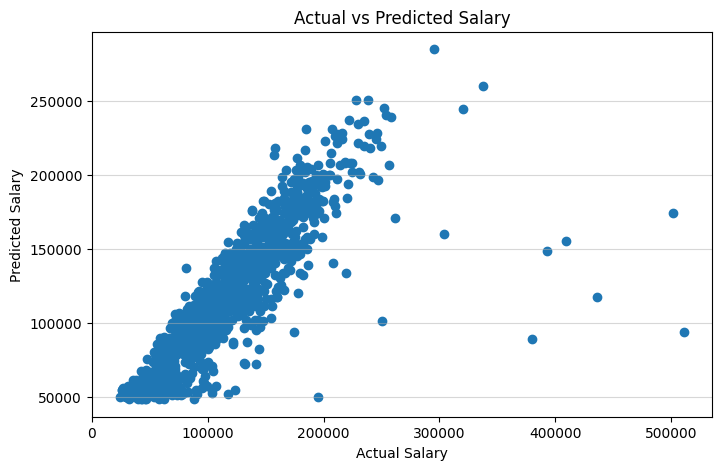

In [33]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_multi_train,
    multi_train_pred
)

plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.grid(axis='y', alpha=0.5)

plt.show()

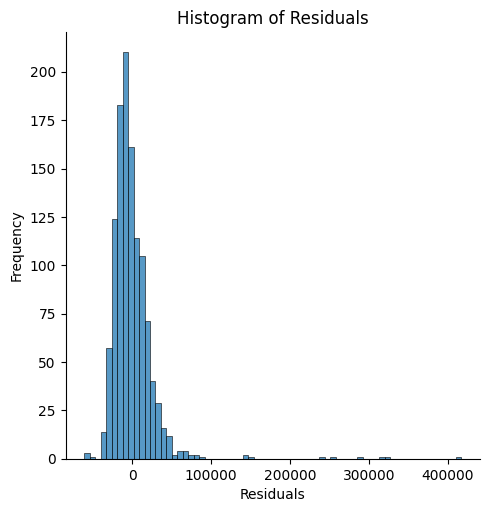

In [34]:
sns.displot(y_multi_train - multi_train_pred)

plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.show()

In [35]:
# Dự đoán mức lương cho một nhân viên mới
new_employee = np.array([16, 39, 5]).reshape(1, -1)

predicted_salary = multi_model.predict(new_employee)

print(
    f"The model predicts that an employee with "
    f"16 years of experience, age 39, and 5 skills "
    f"would have a salary of about {predicted_salary[0]:,.0f} BDT."
)

The model predicts that an employee with 16 years of experience, age 39, and 5 skills would have a salary of about 184,352 BDT.


/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# 3. Polynomial Regression

Polynomial Regression mở rộng hồi quy tuyến tính bằng cách tạo thêm các đặc trưng
lũy thừa và tương tác giữa các biến, từ đó mô hình hóa các mối quan hệ phi tuyến.

Ta sử dụng cùng ba biến độc lập:

- `experience_years`
- `age`
- `skills_count`

và biến mục tiêu `salary_bdt`.

Hai mô hình được xây dựng với:

- **Degree 2**
- **Degree 3**

Sau đó đánh giá trên cả tập Train và Test bằng R², MAE và MSE.

In [36]:
# Degree 2
poly_features_degree2 = PolynomialFeatures(degree=2)

X_train_degree2 = poly_features_degree2.fit_transform(X_multi_train)
X_test_degree2 = poly_features_degree2.transform(X_multi_test)

print("Original number of features:", X_multi_train.shape[1])
print(
    "Number of features after Polynomial Transformation:",
    X_train_degree2.shape[1]
)

Original number of features: 3
Number of features after Polynomial Transformation: 10


In [37]:
quadratic_model = LinearRegression()

quadratic_model.fit(
    X_train_degree2,
    y_multi_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
y_train_degree2_predicted = quadratic_model.predict(X_train_degree2)
y_test_degree2_predicted = quadratic_model.predict(X_test_degree2)

In [39]:
print('Train evaluation for degree 2 polynomial regressor:\n')
print('R²:', metrics.r2_score(y_multi_train, y_train_degree2_predicted))
print('MAE:', metrics.mean_absolute_error(y_multi_train, y_train_degree2_predicted))
print('MSE:', metrics.mean_squared_error(y_multi_train, y_train_degree2_predicted))

Train evaluation for degree 2 polynomial regressor:

R²: 0.6979706800051158
MAE: 16912.045408439164
MSE: 918276345.2371866


In [40]:
print('Test evaluation for degree 2 polynomial regressor:\n')
print('R²:', metrics.r2_score(y_multi_test, y_test_degree2_predicted))
print('MAE:', metrics.mean_absolute_error(y_multi_test, y_test_degree2_predicted))
print('MSE:', metrics.mean_squared_error(y_multi_test, y_test_degree2_predicted))

Test evaluation for degree 2 polynomial regressor:

R²: 0.6000060629541432
MAE: 18022.41185413366
MSE: 1257143320.6231265


In [41]:
# Degree 3
poly_features_degree3 = PolynomialFeatures(degree=3)

X_train_degree3 = poly_features_degree3.fit_transform(X_multi_train)
X_test_degree3 = poly_features_degree3.transform(X_multi_test)

print("Original number of features:", X_multi_train.shape[1])
print(
    "Number of features after Polynomial Transformation:",
    X_train_degree3.shape[1]
)

Original number of features: 3
Number of features after Polynomial Transformation: 20


In [42]:
cubic_model = LinearRegression()

cubic_model.fit(
    X_train_degree3,
    y_multi_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_train_degree3_predicted = cubic_model.predict(X_train_degree3)
y_test_degree3_predicted = cubic_model.predict(X_test_degree3)

In [44]:
print('Train evaluation for degree 3 polynomial regressor:\n')
print('R²:', metrics.r2_score(y_multi_train, y_train_degree3_predicted))
print('MAE:', metrics.mean_absolute_error(y_multi_train, y_train_degree3_predicted))
print('MSE:', metrics.mean_squared_error(y_multi_train, y_train_degree3_predicted))

Train evaluation for degree 3 polynomial regressor:

R²: 0.7007967973954619
MAE: 16885.532756337332
MSE: 909683945.1733046


In [45]:
print('Test evaluation for degree 3 polynomial regressor:\n')
print('R²:', metrics.r2_score(y_multi_test, y_test_degree3_predicted))
print('MAE:', metrics.mean_absolute_error(y_multi_test, y_test_degree3_predicted))
print('MSE:', metrics.mean_squared_error(y_multi_test, y_test_degree3_predicted))

Test evaluation for degree 3 polynomial regressor:

R²: 0.6019256155113799
MAE: 17881.828662639262
MSE: 1251110347.48924


# 4. Logistic Regression

Logistic Regression được sử dụng cho bài toán **phân loại nhị phân**.

Trong bài này, thay vì dự đoán trực tiếp mức lương `salary_bdt`, ta dự đoán một nhân viên
có thuộc nhóm **lương cao** hay không.

Ta tạo biến `target` dựa trên median của `salary_bdt`:

- `target = 0`: `salary_bdt` nhỏ hơn hoặc bằng median.
- `target = 1`: `salary_bdt` lớn hơn median.

Như vậy, bài toán trở thành phân loại hai lớp.

In [46]:
# Kiểm tra dữ liệu trước khi xây dựng Logistic Regression
salary_data.head()

,age,gender,education,experience_years,role_seniority,company_size,location_tier,skills_count,certifications,worked_remote,last_promotion_years_ago,salary_bdt,recent_project_description_length,survey_date,recent_note
0,33,Male,M.Sc,6.0,Senior,Enterprise,Tier-2,1.0,2.0,1,0.0,145185,57.0,2024-11-15,Worked on microservices deployment
1,29,Male,M.Sc,9.0,Junior,Enterprise,Remote,5.0,0.0,1,0.0,121262,50.0,2024-03-08,Built ML pipeline for preprocessing
2,34,Male,B.Sc+Cert,NaN,Lead,Enterprise,Remote,5.0,1.0,1,5.0,184875,50.0,2024-09-01,Experience in data cleaning and ETL
3,39,Male,B.Sc,16.0,Mid,Enterprise,Tier-1,5.0,0.0,1,3.0,180105,59.0,2024-01-26,Contributed to open-source NLP repo
4,29,Female,B.Sc,8.0,Junior,SME,Tier-1,5.0,2.0,0,7.0,114750,NaN,2023-12-08,Built ML pipeline for preprocessing


In [47]:
salary_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                2000 non-null   int64  
 1   gender                             2000 non-null   object 
 2   education                          1900 non-null   object 
 3   experience_years                   1840 non-null   float64
 4   role_seniority                     2000 non-null   object 
 5   company_size                       2000 non-null   object 
 6   location_tier                      2000 non-null   object 
 7   skills_count                       1800 non-null   float64
 8   certifications                     1920 non-null   float64
 9   worked_remote                      2000 non-null   int64  
 10  last_promotion_years_ago           1880 non-null   float64
 11  salary_bdt                         2000 non-null   int64

In [48]:
salary_data.isna().sum()

age                                    0
gender                                 0
education                            100
experience_years                     160
role_seniority                         0
company_size                           0
location_tier                          0
skills_count                         200
certifications                        80
worked_remote                          0
last_promotion_years_ago             120
salary_bdt                             0
recent_project_description_length    240
survey_date                            0
recent_note                          300
dtype: int64

### Tạo biến mục tiêu `target`

Median được tính từ toàn bộ `salary_bdt`. Sau đó, các mức lương lớn hơn median
được gán nhãn 1 và các mức lương còn lại được gán nhãn 0.

`salary_bdt` không được đưa vào biến đầu vào của Logistic Regression vì nó đã được
sử dụng để tạo `target`. Nếu dùng lại `salary_bdt` làm feature sẽ gây data leakage.

In [49]:
salary_median = salary_data['salary_bdt'].median()

salary_data['target'] = (
    salary_data['salary_bdt'] > salary_median
).astype(int)

print("Salary median:", salary_median)

salary_data[['salary_bdt', 'target']].head(10)

Salary median: 111433.5


,salary_bdt,target
0,145185,1
1,121262,1
2,184875,1
3,180105,1
4,114750,1
5,88150,0
6,210347,1
7,168940,1
8,74069,0
9,117598,1


In [50]:
# Kiểm tra số lượng và tỷ lệ của hai lớp
print(salary_data['target'].value_counts())
print()
print(salary_data['target'].value_counts(normalize=True))

target
1    1000
0    1000
Name: count, dtype: int64

target
1    0.5
0    0.5
Name: proportion, dtype: float64


### Chọn biến đầu vào

Để giữ mô hình đơn giản và dễ diễn giải, ta sử dụng bốn biến số:

- `experience_years`: số năm kinh nghiệm.
- `age`: tuổi.
- `skills_count`: số lượng kỹ năng.
- `certifications`: số lượng chứng chỉ.

Các dòng có giá trị thiếu ở các biến này sẽ được loại bỏ.

In [51]:
logistic_features = [
    'experience_years',
    'age',
    'skills_count',
    'certifications'
]

logistic_data = salary_data[
    logistic_features + ['target']
].dropna()

print("Original shape:", salary_data.shape)
print("Shape after removing missing values:", logistic_data.shape)

Original shape: (2000, 16)
Shape after removing missing values: (1595, 5)


In [52]:
X_log = logistic_data[logistic_features]
y_log = logistic_data['target']

print("X shape:", X_log.shape)
print("y shape:", y_log.shape)

X shape: (1595, 4)
y shape: (1595,)


### Chia dữ liệu thành Train và Test

Sử dụng 70% dữ liệu để huấn luyện và 30% để kiểm tra.

`stratify=y_log` giúp giữ tỷ lệ hai lớp `target = 0` và `target = 1`
tương đối giống nhau ở cả hai tập.

In [53]:
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log,
    y_log,
    test_size=0.3,
    random_state=4,
    stratify=y_log
)

print("X_log_train:", X_log_train.shape)
print("X_log_test:", X_log_test.shape)
print("y_log_train:", y_log_train.shape)
print("y_log_test:", y_log_test.shape)

X_log_train:

 (1116, 4)
X_log_test: (479, 4)
y_log_train: (1116,)
y_log_test: (479,)


### Chuẩn hóa dữ liệu

Các biến số có thang đo khác nhau nên được chuẩn hóa bằng `StandardScaler`.

Scaler chỉ được `fit` trên tập Train, sau đó dùng để biến đổi cả Train và Test.
Cách này tránh sử dụng thông tin của Test trong quá trình huấn luyện.

In [54]:
scaler_log = StandardScaler()

X_log_train_scaled = scaler_log.fit_transform(X_log_train)
X_log_test_scaled = scaler_log.transform(X_log_test)

print("Scaled training data shape:", X_log_train_scaled.shape)
print("Scaled test data shape:", X_log_test_scaled.shape)

Scaled training data shape: (1116, 4)
Scaled test data shape: (479, 4)


### Huấn luyện Logistic Regression

Mô hình học mối quan hệ giữa các đặc trưng và xác suất một nhân viên thuộc
nhóm `target = 1` (lương cao).

Mô hình sử dụng ngưỡng mặc định 0.5 để chuyển xác suất thành nhãn 0 hoặc 1.

In [55]:
logistic_model = LogisticRegression()

logistic_model.fit(
    X_log_train_scaled,
    y_log_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [56]:
# Dự đoán nhãn và xác suất trên tập Test
y_log_pred = logistic_model.predict(X_log_test_scaled)
y_log_prob = logistic_model.predict_proba(X_log_test_scaled)[:, 1]

print("Predicted labels:")
print(y_log_pred[:10])

print("\nPredicted probabilities:")
print(y_log_prob[:10])

Predicted labels:
[0 0 0 1 1 1 1 1 1 1]

Predicted probabilities:
[0.00991489 0.01021124 0.47251623 0.73117137 0.87344968 0.99401974
 0.54451161 0.95773205 0.99912508 0.94682275]


### Đánh giá Logistic Regression

Các chỉ số được sử dụng:

- **Accuracy:** tỷ lệ dự đoán đúng trên tổng số mẫu.
- **Precision:** trong các mẫu được dự đoán là lương cao, có bao nhiêu mẫu thực sự thuộc nhóm lương cao.
- **Recall:** trong các mẫu thực sự thuộc nhóm lương cao, mô hình nhận diện được bao nhiêu mẫu.
- **F1-score:** trung bình điều hòa giữa Precision và Recall.
- **Log Loss:** đánh giá chất lượng của xác suất dự đoán; càng thấp càng tốt.
- **AUC:** khả năng phân biệt hai lớp của mô hình; giá trị càng gần 1 thể hiện khả năng phân biệt càng tốt.

In [57]:
print("Accuracy:", accuracy_score(y_log_test, y_log_pred))
print("Precision:", precision_score(y_log_test, y_log_pred))
print("Recall:", recall_score(y_log_test, y_log_pred))
print("F1-score:", f1_score(y_log_test, y_log_pred))
print("Log Loss:", log_loss(y_log_test, y_log_prob))
print("AUC:", roc_auc_score(y_log_test, y_log_prob))
print("Average Precision:", average_precision_score(y_log_test, y_log_prob))

Accuracy: 0.9102296450939458
Precision: 0.9125
Recall: 0.9087136929460581
F1-score: 0.9106029106029107
Log Loss: 0.2189287244499256
AUC: 0.9751386031591059
Average Precision: 0.9778646897557922


In [58]:
print("Classification Report")
print(
    classification_report(
        y_log_test,
        y_log_pred
    )
)

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       238
           1       0.91      0.91      0.91       241

    accuracy                           0.91       479
   macro avg       0.91      0.91      0.91       479
weighted avg       0.91      0.91      0.91       479



### Confusion Matrix

Confusion Matrix cho biết số lượng dự đoán đúng và sai của mô hình đối với
hai lớp `target = 0` và `target = 1`.

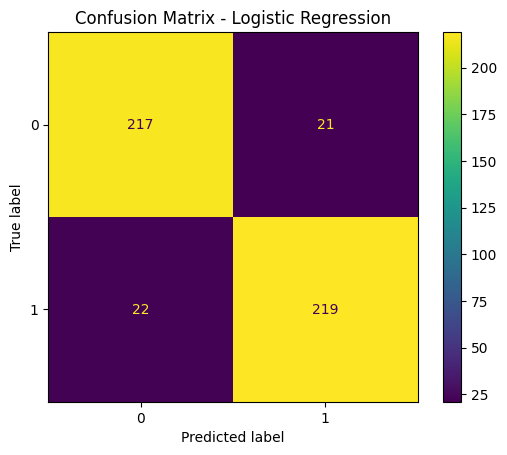

In [59]:
ConfusionMatrixDisplay.from_predictions(
    y_log_test,
    y_log_pred
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### ROC Curve

ROC Curve biểu diễn khả năng phân biệt hai lớp của mô hình khi thay đổi
ngưỡng phân loại. AUC là diện tích dưới đường ROC.

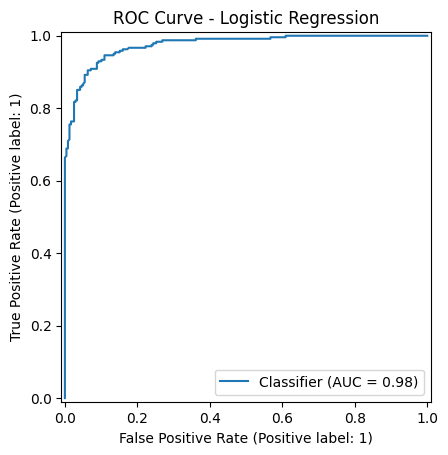

In [60]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_log_test,
    y_log_prob
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

### Hệ số của Logistic Regression

Các hệ số cho biết chiều hướng thay đổi của **log-odds** khi một biến thay đổi,
trong khi các biến khác được giữ cố định.

- Hệ số dương: biến có xu hướng làm tăng xác suất thuộc nhóm `target = 1`.
- Hệ số âm: biến có xu hướng làm giảm xác suất thuộc nhóm `target = 1`.

Do các biến đã được chuẩn hóa, hệ số của biến số được diễn giải theo một độ lệch chuẩn
của biến đó.

In [61]:
logistic_coefficients = pd.DataFrame({
    'Feature': logistic_features,
    'Coefficient': logistic_model.coef_[0]
})

logistic_coefficients

,Feature,Coefficient
0,experience_years,3.188807
1,age,0.583938
2,skills_count,0.155883
3,certifications,0.187981


In [62]:
# Odds Ratio = exp(Coefficient)
logistic_coefficients['Odds_Ratio'] = np.exp(
    logistic_coefficients['Coefficient']
)

logistic_coefficients

,Feature,Coefficient,Odds_Ratio
0,experience_years,3.188807,24.259476
1,age,0.583938,1.793086
2,skills_count,0.155883,1.168689
3,certifications,0.187981,1.206810


### Kết luận ngắn cho Logistic Regression

Mô hình Logistic Regression được sử dụng để phân loại nhân viên thành hai nhóm
dựa trên median của `salary_bdt`: nhóm không cao (`0`) và nhóm cao (`1`).

Các chỉ số Accuracy, Precision, Recall, F1-score, Log Loss và AUC được sử dụng
để đánh giá hiệu quả mô hình. Các hệ số và Odds Ratio giúp giải thích chiều hướng
liên hệ giữa các đặc trưng và khả năng thuộc nhóm lương cao.